In [ ]:
import collections
import math
import torch

from torch import nn
from d2l import torch as d2l

# English Source
# -> Encoder GRU
# -> Encoded State
# -> Decoder GRU + Teacher Forcing
# -> Masked Cross-Entropy
# -> Training
# -> Autoregressive Prediction
# -> BLEU Evaluation

In [6]:
# Sequence-To-Sequence Parameter Initialization

def init_seq2seq(
    module: nn.Module,
) -> None:
    
    if type(module) is nn.Linear:
        nn.init.xavier_uniform_(
            module.weight
        )

    if type(module) is nn.GRU:        
        for name, parameter in module.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(
                    parameter
                )


# Sequence-to-Sequence Encoder

class Seq2SeqEncoder(d2l.Encoder):
    
    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        num_hiddens: int,
        num_layers: int,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_size,
        )
        
        self.rnn = d2l.GRU(
            num_inputs=embed_size,
            num_hiddens=num_hiddens,
            num_layers=num_layers,
            dropout=dropout,
        )
        
        self.apply(
            init_seq2seq
        )
        
        
    def forward(
        self,
        X: torch.Tensor,
        *args: object,
    ) -> tuple[
        torch.Tensor,
        torch.Tensor,  
    ]:
        
        # [nn.Embedding]:
        # [B, T] -> [T, B] -> [T, B, E]
        embeddings = self.embedding(
            X.T.to(dtype=torch.long)
        )
        
        # [nn.GRU]: 
        # inputs : [T, B, E]
        # outputs: [T, B, H]
        # state  : [L, B, H]
        outputs, state = self.rnn(
            embeddings 
        )
        
        return outputs, state


# Sequence-To-Sequence Decoder

class Seq2SeqDecoder(d2l.Decoder):
    
    def __init__(
        self,
        vocab_size: int,
        embed_size: int,
        num_hiddens: int,
        num_layers: int,
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_size,
        )
        
        self.rnn = d2l.GRU(
            num_inputs=embed_size + num_hiddens,
            num_hiddens=num_hiddens,
            num_layers=num_layers,
            dropout=dropout,
        )
        
        self.dense = nn.LazyLinear(
            out_features=vocab_size
        )
        
        self.apply(
            init_seq2seq
        )
        
        
    def init_state(
        self,
        enc_all_outputs: tuple[
            torch.Tensor,
            torch.Tensor,
        ],
        *args: object,
    ) -> tuple[
        torch.Tensor,
        torch.Tensor,
    ]:
        return enc_all_outputs
    
    
    def forward(
        self,
        X: torch.Tensor,
        state: tuple[
            torch.Tensor,
            torch.Tensor,
        ],
    ) -> tuple[
        torch.Tensor,
        tuple[torch.Tensor, torch.Tensor],
    ]:
    
        # Decoder input X: [B, T]
        # [B, T] -> [T, B] -> [T, B, E]
        embeddings = self.embedding(
            X.T.to(dtype=torch.long)
        )

        # encoder_outputs: [T, B, H]
        # hidden_state   : [L, B, H]
        encoder_outputs, hidden_state = state

        # Encoder의 마지막 time step 선택
        # [T, B, H] -> [B, H]
        context = encoder_outputs[-1]

        # time step T개로 복사
        # [B, H] -> [T, B, H]
        context = context.repeat(
            embeddings.shape[0], # T
            1, 
            1,
        )
        
        # Feature dimension으로 Concatenate:
        # [T, B, E] + [T, B, H] -> [T, B, E + H]
        embeddings_and_context = torch.cat(
            (embeddings, context),
            dim=-1,
        )
        
        # Forward into GRU
        # outputs      : [T, B, H]
        # hidden_state : [L, B, H]
        outputs, hidden_state = self.rnn(
            embeddings_and_context,
            hidden_state,
        )
        
        # Linear: H → V & 축 교환
        # [T, B, H] -> [T, B, V] -> [B, T, V]
        outputs = self.dense(
            outputs
        ).swapaxes(0, 1)
        
        
        return outputs, (
            encoder_outputs,
            hidden_state,
        )


# Sequence-to-Sequence Model

class Seq2Seq(d2l.EncoderDecoder):
    def __init__(
        self,
        encoder: Seq2SeqEncoder,
        decoder: Seq2SeqDecoder,
        tgt_pad: int,
        lr: float,
    ) -> None:
        super().__init__(
            encoder,
            decoder,
        )
        
        self.tgt_pad = tgt_pad
        self.lr = lr

    def validation_step(
        self,
        batch: tuple[
            torch.Tensor,
            torch.Tensor,
            torch.Tensor,
            torch.Tensor,
        ],
    ) -> None:
        predictions = self(
            *batch[:-1]
        )

        loss = self.loss(
            predictions,
            batch[-1],
        )

        self.plot(
            "loss",
            loss,
            train=False,
        )

    def configure_optimizers(
        self,
    ) -> torch.optim.Optimizer:
        return torch.optim.Adam(
            self.parameters(),
            lr=self.lr,
        )


# Masked Cross-Entropy loss

def seq2seq_loss(
    self: Seq2Seq,
    predictions: torch.Tensor,
    labels: torch.Tensor,
) -> torch.Tensor:
    
    token_losses = super(
        Seq2Seq,
        self,
    ).loss(
        predictions,
        labels,
        averaged = False,
    )
    
    # 실제 Token: 1
    # <pad>:     0
    mask = (
        labels.reshape(-1)
        != self.tgt_pad
    ).to(dtype=torch.float32)

    # <pad>를 제외한 실제 Token Loss의 평균
    return (
        token_losses * mask
    ).sum() / mask.sum()


setattr(
    Seq2Seq,
    "loss",
    seq2seq_loss,
)

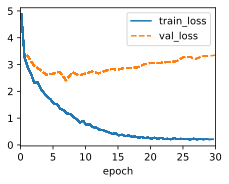

In [7]:
# Sequence-to-Sequence Training

data = d2l.MTFraEng(
    batch_size=128
)

embed_size = 256
num_hiddens = 256
num_layers = 2
dropout = 0.2

encoder = Seq2SeqEncoder(
    vocab_size=len(data.src_vocab),
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
    dropout=dropout,
)

decoder = Seq2SeqDecoder(
    vocab_size=len(data.tgt_vocab),
    embed_size=embed_size,
    num_hiddens=num_hiddens,
    num_layers=num_layers,
    dropout=dropout,
)

model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    tgt_pad=data.tgt_vocab["<pad>"],
    lr=0.005,
)

num_gpus = (
    1
    if torch.cuda.is_available()
    else 0
)

device_name = (
    torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
)

print(
    "Training device:",
    device_name,
)

trainer = d2l.Trainer(
    max_epochs=30,
    gradient_clip_val=1,
    num_gpus=num_gpus,
)

trainer.fit(
    model,
    data,
)

In [8]:
# Autoregressive Prediction

def seq2seq_predict_step(
    self: Seq2Seq,
    batch: tuple[
        torch.Tensor,
        torch.Tensor,
        torch.Tensor,
        torch.Tensor,
    ],
    device: torch.device,
    num_steps: int,
    save_attention_weights: bool = False,
) -> tuple[
    torch.Tensor,
    list[object],
]:
    batch_on_device = tuple(
        tensor.to(device)
        for tensor in batch
    )

    (
        source,
        target,
        source_valid_len,
        _,
    ) = batch_on_device

    # English source를 Encode
    encoder_outputs = self.encoder(
        source,
        source_valid_len,
    )

    # Encoder output으로 Decoder state 초기화
    decoder_state = self.decoder.init_state(
        encoder_outputs,
        source_valid_len,
    )

    # 첫 Decoder input은 <bos>
    predictions = [
        target[:, 0].unsqueeze(1)
    ]

    attention_weights: list[object] = []

    for _ in range(num_steps):
        # 이전에 예측한 Token을 Decoder input으로 사용
        logits, decoder_state = self.decoder(
            predictions[-1],
            decoder_state,
        )

        # Vocabulary에서 가장 높은 logit의 Token 선택
        next_token = logits.argmax(
            dim=2
        )

        predictions.append(
            next_token
        )

        if save_attention_weights:
            attention_weights.append(
                getattr(
                    self.decoder,
                    "attention_weights",
                )
            )

    return (
        torch.cat(
            predictions[1:],
            dim=1,
        ),
        attention_weights,
    )


setattr(
    Seq2Seq,
    "predict_step",
    seq2seq_predict_step,
)

In [9]:
# BLEU Score

def bleu(
    predicted_sequence: str,
    label_sequence: str,
    k: int,
) -> float:
    predicted_tokens = predicted_sequence.split()
    label_tokens = label_sequence.split()

    predicted_length = len(
        predicted_tokens
    )
    label_length = len(
        label_tokens
    )

    if predicted_length == 0:
        return 0.0

    # Brevity Penalty
    score = math.exp(
        min(
            0,
            1 - label_length / predicted_length,
        )
    )

    for n in range(
        1,
        min(k, predicted_length) + 1,
    ):
        num_matches = 0

        label_subsequences: collections.defaultdict[
            str,
            int,
        ] = collections.defaultdict(int)

        # 정답의 n-gram 개수 기록
        for index in range(
            label_length - n + 1
        ):
            ngram = " ".join(
                label_tokens[
                    index:index + n
                ]
            )

            label_subsequences[ngram] += 1

        # Prediction의 n-gram과 비교
        for index in range(
            predicted_length - n + 1
        ):
            ngram = " ".join(
                predicted_tokens[
                    index:index + n
                ]
            )

            if label_subsequences[ngram] > 0:
                num_matches += 1
                label_subsequences[ngram] -= 1

        precision = (
            num_matches
            / (predicted_length - n + 1)
        )

        score *= math.pow(
            precision,
            math.pow(0.5, n),
        )

    return score

In [10]:
# Translation and BLEU Evaluation

english_sentences = [
    "go .",
    "i lost .",
    "he's calm .",
    "i'm home .",
]

french_sentences = [
    "va !",
    "j'ai perdu .",
    "il est calme .",
    "je suis chez moi .",
]

model_device = next(
    model.parameters()
).device

predictions, _ = model.predict_step(
    data.build(
        english_sentences,
        french_sentences,
    ),
    model_device,
    data.num_steps,
)

for english, french, prediction in zip(
    english_sentences,
    french_sentences,
    predictions.cpu(),
):
    translation: list[str] = []

    for token in data.tgt_vocab.to_tokens(
        prediction
    ):
        if token == "<eos>":
            break

        translation.append(token)

    translation_text = " ".join(
        translation
    )

    score = bleu(
        translation_text,
        french,
        k=2,
    )

    print(
        f"{english} => {translation}, "
        f"BLEU: {score:.3f}"
    )

go . => ['va', '!'], BLEU: 1.000
i lost . => ["j'ai", 'perdu', '.'], BLEU: 1.000
he's calm . => ['assieds-toi', '.'], BLEU: 0.000
i'm home . => ['je', 'suis', 'chez', 'moi', '.'], BLEU: 1.000
